# CSIR Biomass - Exploratory Data Analysis

This notebook explores the training data for the CSIR Biomass prediction competition.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)


## Load Data


In [3]:
# Load training data
train_df = pd.read_csv('../data/raw/train.csv')
test_df = pd.read_csv('../data/raw/test.csv')

print(f"Training samples: {len(train_df)}")
print(f"Test samples: {len(test_df)}")
print(f"\nUnique images in training: {train_df['image_path'].nunique()}")
print(f"Unique images in test: {test_df['image_path'].nunique()}")

train_df.head(10)


Training samples: 1785
Test samples: 5

Unique images in training: 357
Unique images in test: 1


,sample_id,image_path,Sampling_Date,State,Species,Pre_GSHH_NDVI,Height_Ave_cm,target_name,target
0,ID1011485656__Dry_Clover_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Clover_g,0.0000
1,ID1011485656__Dry_Dead_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Dead_g,31.9984
2,ID1011485656__Dry_Green_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Green_g,16.2751
3,ID1011485656__Dry_Total_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Total_g,48.2735
4,ID1011485656__GDM_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,GDM_g,16.2750
5,ID1012260530__Dry_Clover_g,train/ID1012260530.jpg,2015/4/1,NSW,Lucerne,0.55,16.0000,Dry_Clover_g,0.0000
6,ID1012260530__Dry_Dead_g,train/ID1012260530.jpg,2015/4/1,NSW,Lucerne,0.55,16.0000,Dry_Dead_g,0.0000
7,ID1012260530__Dry_Green_g,train/ID1012260530.jpg,2015/4/1,NSW,Lucerne,0.55,16.0000,Dry_Green_g,7.6000
8,ID1012260530__Dry_Total_g,train/ID1012260530.jpg,2015/4/1,NSW,Lucerne,0.55,16.0000,Dry_Total_g,7.6000
9,ID1012260530__GDM_g,train/ID1012260530.jpg,2015/4/1,NSW,Lucerne,0.55,16.0000,GDM_g,7.6000


In [ ]:
def month_to_season(month):
    """Maps month (int) to season (str) for Southern Hemisphere (Australia)."""
    if month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Fall'
    else:
        return 'Winter'
train_df['season'] = pd.to_datetime(train_df['Sampling_Date']).dt.month.map(month_to_season)
# Show a table of the number of unique sampling dates by season and state
season_state_table = train_df.groupby(['season', 'State'])['Sampling_Date'].nunique().unstack().fillna(0).astype(int)
display(season_state_table.style.background_gradient(cmap='YlGnBu').set_caption("Unique Sampling Dates by Season and State"))

season  State
Fall    NSW       55
        Tas      355
        Vic      195
        WA        60
Spring  NSW      115
        Tas      145
Summer  Tas      190
        Vic      365
        WA       100
Winter  NSW      205
Name: Sampling_Date, dtype: int64

## Target Distribution Analysis


Summary statistics for each target:
target_name  Dry_Clover_g  Dry_Dead_g  Dry_Green_g  Dry_Total_g       GDM_g
count          357.000000  357.000000   357.000000   357.000000  357.000000
mean             6.649692   12.044548    26.624722    45.318097   33.274414
std             12.117761   12.402007    25.401232    27.984015   24.935822
min              0.000000    0.000000     0.000000     1.040000    1.040000
25%              0.000000    3.200000     8.800000    25.271500   16.026100
50%              1.423500    7.980900    20.800000    40.300000   27.108200
75%              7.242900   17.637800    35.083400    57.880000   43.675700
max             71.786500   83.840700   157.983600   185.700000  157.983600
target_name
Dry_Clover_g    0.621849
Dry_Dead_g      0.887955
Dry_Green_g     0.949580
Dry_Total_g     1.000000
GDM_g           1.000000
dtype: float64


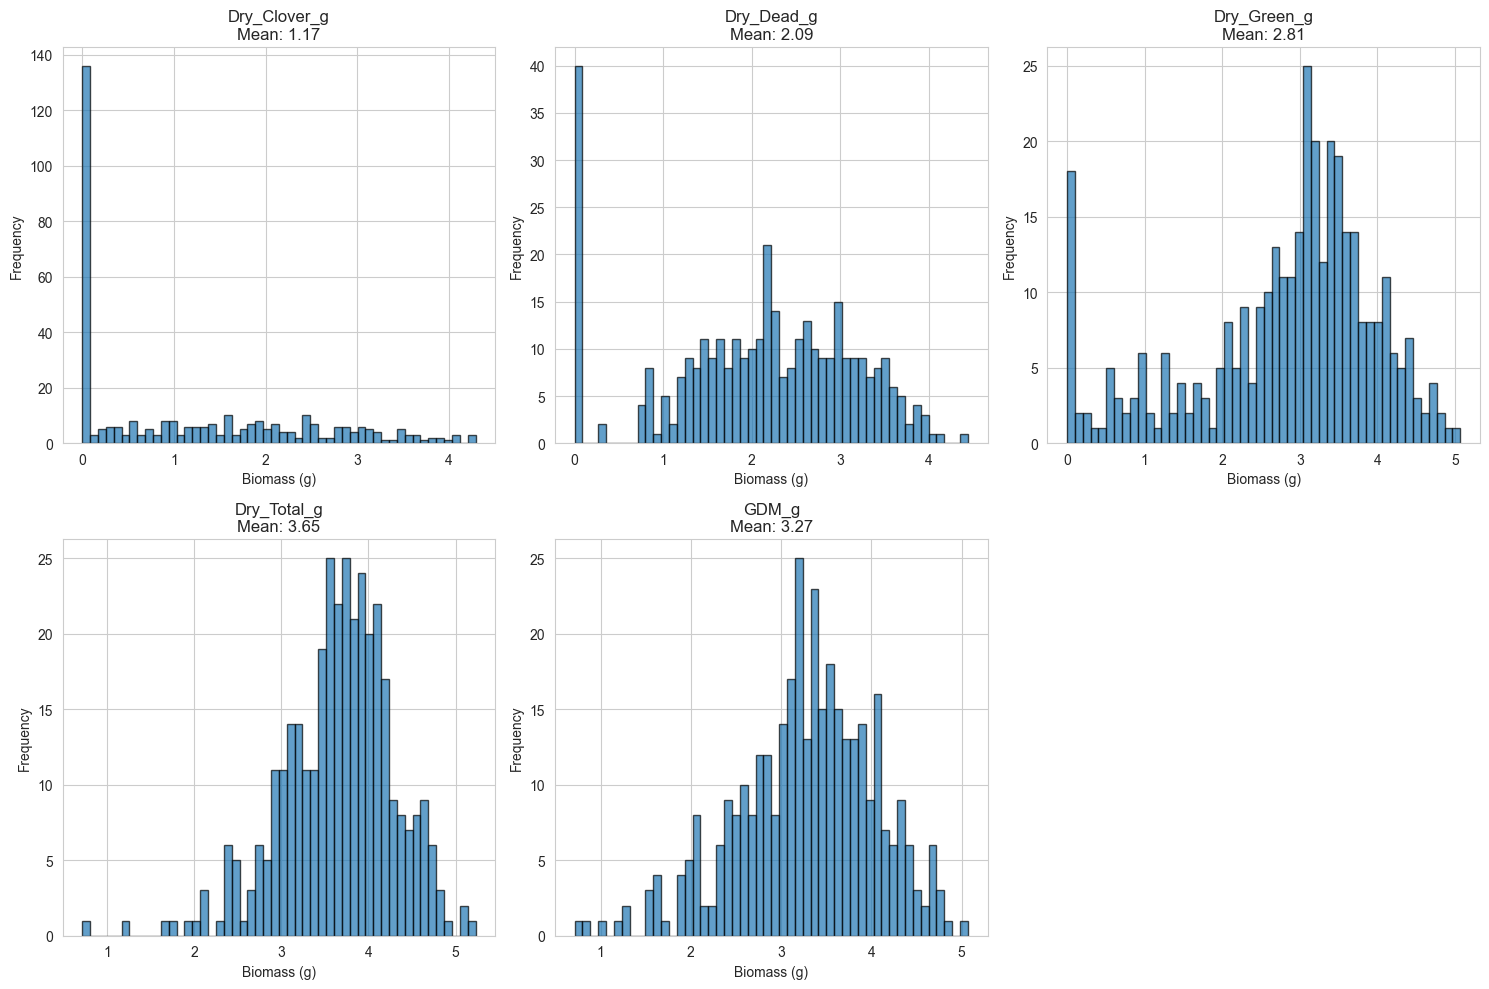

In [5]:
# Pivot to get all targets per image
targets_pivot = train_df.pivot_table(
    index='image_path',
    columns='target_name',
    values='target',
    aggfunc='first'
)

print("Summary statistics for each target:")
print(targets_pivot.describe())

print(targets_pivot.gt(0).mean())

# Plot distribution
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# apply logarithm to everything
import numpy as np
targets_pivot = np.log1p(targets_pivot)


for i, target in enumerate(sorted(targets_pivot.columns)):
    axes[i].hist(targets_pivot[target], bins=50, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{target}\nMean: {targets_pivot[target].mean():.2f}')
    axes[i].set_xlabel('Biomass (g)')
    axes[i].set_ylabel('Frequency')

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()


## Target Correlations


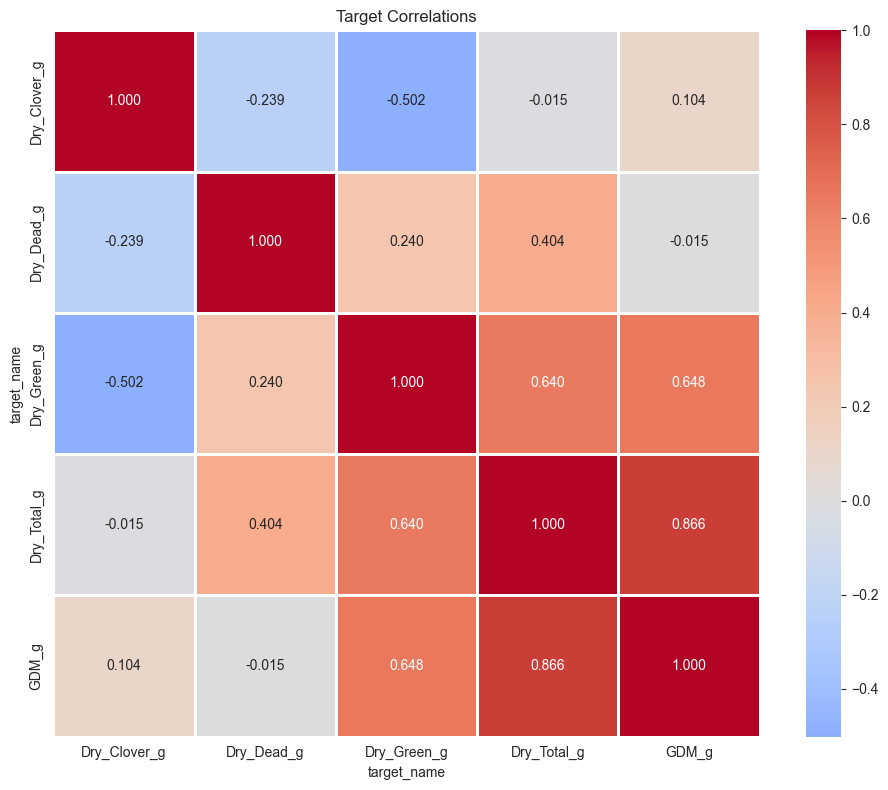


Correlation with Dry_Total_g:
target_name
Dry_Total_g     1.000000
GDM_g           0.865775
Dry_Green_g     0.640369
Dry_Dead_g      0.403598
Dry_Clover_g   -0.015081
Name: Dry_Total_g, dtype: float64


In [6]:
# Correlation matrix
plt.figure(figsize=(10, 8))
correlation = targets_pivot.corr()
sns.heatmap(correlation, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1)
plt.title('Target Correlations')
plt.tight_layout()
plt.show()

print("\nCorrelation with Dry_Total_g:")
print(correlation['Dry_Total_g'].sort_values(ascending=False))


## Sample Images


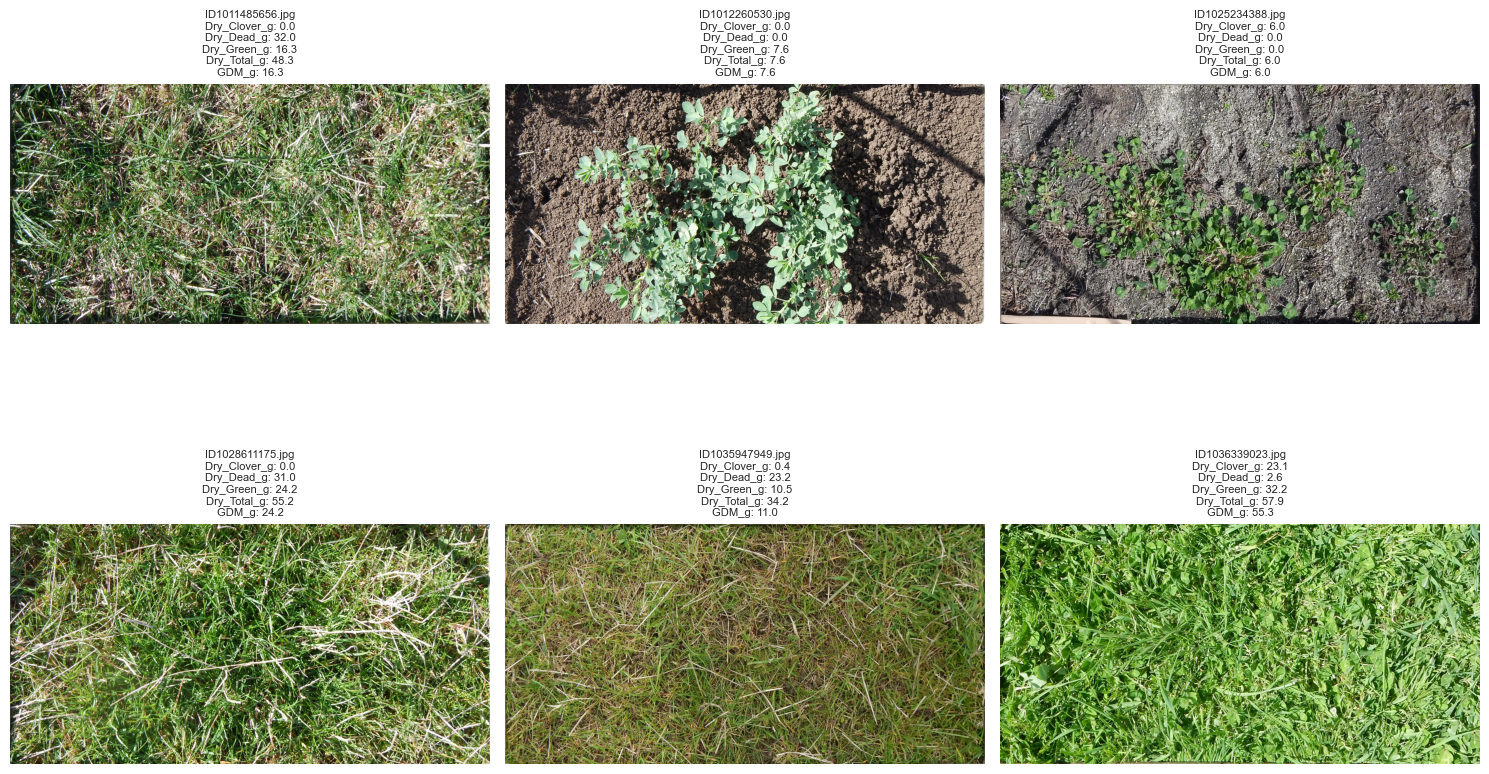

In [7]:
# Visualize sample images with their targets
sample_images = train_df['image_path'].unique()[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, img_path in enumerate(sample_images):
    full_path = Path('../data/raw') / img_path
    if full_path.exists():
        img = Image.open(full_path)
        axes[i].imshow(img)
        axes[i].axis('off')
        
        # Get targets for this image
        targets = train_df[train_df['image_path'] == img_path][['target_name', 'target']]
        target_text = '\n'.join([f"{row['target_name']}: {row['target']:.1f}" for _, row in targets.iterrows()])
        axes[i].set_title(f"{Path(img_path).name}\n{target_text}", fontsize=8)

plt.tight_layout()
plt.show()
